# 00 Orientation: What Is a Data Cube and Why Does It Matter?

**Tutorial:** Building Geospatial Data Cubes for Earth Data Science  
**Focus:** Pine Ridge (Oglala Lakota), South Dakota  
**Prerequisites:** Python basics (variables, lists, functions)  

## Before You Start
Please read `docs/data_sovereignty.md` before continuing. The data in
this tutorial describes Oglala Lakota and other Tribal lands. That carries
responsibilities that this notebook will not repeat, but that context
matters for everything you build here.

## A Question About the Land
Here is a question a land manager at Pine Ridge might ask:

> *"What has the vegetation condition looked like on Pine Ridge over the
> last 24 years, and how does it relate to drought years?"*

To answer this question with data, you need three things at once:

1. **Space**: data that covers Pine Ridge specifically
2. **Time**: observations from many years, not just one snapshot
3. **Multiple variables**: vegetation greenness AND drought index, so you can
   see the relationship between them

A **data cube** is a data structure that holds all three dimensions together.

## The Problem with Spreadsheets
Imagine you have monthly satellite images of Pine Ridge going back to 2000.
That's about 300 images. Each image is a grid of pixels, say, 200 × 200
pixels covering the reservation.

If you tried to store this in a spreadsheet:
- Each row could be one pixel location
- Each column could be one month
- You'd have 40,000 rows × 300 columns = 12 million cells
- And you haven't added any climate variables yet

Spreadsheets are the wrong tool for this problem. They lose the spatial
structure (which pixels are neighbors?), they're slow for time series
operations, and they can't hold multiple variables cleanly.

## The Data Cube Solution
A data cube organizes the same information as a 3D structure:

```
         time →
        Jan Feb Mar ... Dec
   lat  ┌───┬───┬───┬───┐
    ↓   │ 0.4│0.3│0.5│...│  ← NDVI values
        │ 0.5│0.4│0.6│...│
        │ ...│...│...│...│
        └───┴───┴───┴───┘
              lon →
```

Now you can ask questions like:
- "Give me all pixels for August 2012" by slicing along the time dimension
- "Give me the time series for this one location" by slicing along lat/lon
- "Give me the average across all pixels for each year" by reducing the spatial dimensions

And when you add climate variables, you get a **multi-variable cube** where
every pixel has both NDVI and temperature and precipitation, all aligned
in space and time.

## What You Will Build in This Tutorial
By the end of notebook 06, you will have built a data cube that:
- Covers Pine Ridge from 2000 to 2024
- Contains NDVI (vegetation greenness), temperature, and precipitation
- Can answer questions about seasonal patterns, drought years, and trends
- Has provenance metadata that documents where the data came from and
  whose land it describes

In notebook 07, you will see how Open Data Cube (ODC) extends this
concept to production-scale systems managing terabytes of satellite data.

In notebook 08, you will define your own question and build a cube to
answer it.

## The Python Libraries We Will Use
| Library | What it does |
|---|---|
| `numpy` | Fast N-dimensional arrays is the foundation |
| `xarray` | Labeled arrays with named dimensions and coordinates |
| `rioxarray` | Adds geospatial capabilities to xarray (CRS, clip, reproject) |
| `geopandas` | Vector data for Tribal boundaries, points, lines |
| `matplotlib` | Visualization |

New libraries will be introduced as they are needed. You don't need to
understand all of them before starting.

## Let's Start: The Simplest Possible Cube
The cell below builds the smallest useful data cube: three years of
monthly temperature at a single location (the center of Pine Ridge).

In [1]:
# The simplest data cube: one location, one variable, multiple time steps
# No geospatial libraries needed yet, we'll just use numpy and xarray to start with.

import numpy as np
import xarray as xr
import pandas as pd

# Imagine we measured monthly temperature at the center of Pine Ridge
# for three years. These are made-up numbers just to illustrate the concept.
# (In notebook 02 we will use real data.)

months = pd.date_range(start="2020-01-01", end="2022-12-01", freq="MS")

# Synthetic temperature values (°F): a rough seasonal pattern for Pine Ridge
np.random.seed(42)
temp_values = (
    np.sin((months.month - 3) * np.pi / 6) * 35 + 50
    + np.random.normal(0, 3, len(months))
)

# This is just a numpy array with no labels
print("numpy array (no labels):")
print(temp_values[:6].round(1))
print(f"Shape: {temp_values.shape}")

numpy array (no labels):
Index([21.2, 32.1, 51.9, 72.1, 79.6, 84.3], dtype='float64')
Shape: (36,)


In [2]:
# Now make it a labeled DataArray. This is the first step toward building a data cube

temp_da = xr.DataArray(
    data   = temp_values,           # the numbers
    coords = {"time": months},      # the labels for each value
    dims   = ["time"],              # the name of the dimension
    name   = "temperature_f",       # the name of this variable
    attrs  = {                      # metadata about this variable
        "units":       "degrees Fahrenheit",
        "location":    "Pine Ridge, Oglala Lakota Nation",
        "description": "Monthly mean temperature",
    }
)

print(temp_da)

<xarray.DataArray 'temperature_f' (time: 36)> Size: 288B
array([21.179253, 32.085207, 51.943066, 72.06909 , 79.608429, 84.297589,
       85.048528, 69.802304, 48.591577, 34.12768 , 18.298858, 13.602811,
       20.414998, 26.760159, 44.825247, 65.813137, 77.272396, 85.942742,
       77.586817, 63.263089, 54.396946, 31.822671, 19.891695, 10.725755,
       18.055963, 32.832768, 46.547019, 68.627094, 78.508973, 84.124919,
       78.505769, 73.056835, 49.959508, 29.326867, 22.156746, 11.337469])
Coordinates:
  * time     (time) datetime64[us] 288B 2020-01-01 2020-02-01 ... 2022-12-01
Attributes:
    units:        degrees Fahrenheit
    location:     Pine Ridge, Oglala Lakota Nation
    description:  Monthly mean temperature


In [3]:
# The difference: with labels, we can select by meaning, not by position

# numpy: "give me position 12" (what month is that?)
print("numpy position 12:", temp_values[12].round(1))

# xarray: "give me January 2021" (clear and readable)
print("xarray January 2021:", float(temp_da.sel(time="2021-01-01").round(1)))

numpy position 12: 20.4
xarray January 2021: 20.4


In [4]:
# xarray makes time operations intuitive

# Mean temperature by month (seasonal climatology)
monthly_mean = temp_da.groupby("time.month").mean()
print("Mean temperature by month:")
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
for month, val in zip(month_names, monthly_mean.values):
    print(f"  {month}: {val:.1f}°F")

Mean temperature by month:
  Jan: 19.9°F
  Feb: 30.6°F
  Mar: 47.8°F
  Apr: 68.8°F
  May: 78.5°F
  Jun: 84.8°F
  Jul: 80.4°F
  Aug: 68.7°F
  Sep: 51.0°F
  Oct: 31.8°F
  Nov: 20.1°F
  Dec: 11.9°F


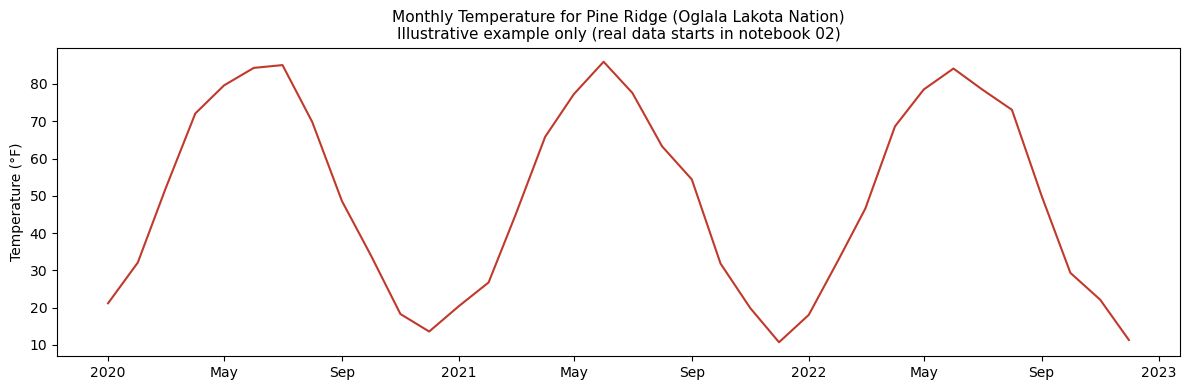

In [5]:
# Plot it! xarray has built-in plotting
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
temp_da.plot(ax=ax, color="#C0392B", linewidth=1.5)
ax.set_title(
    "Monthly Temperature for Pine Ridge (Oglala Lakota Nation)\n"
    "Illustrative example only (real data starts in notebook 02)",
    fontsize=11,
)
ax.set_xlabel("")
ax.set_ylabel("Temperature (°F)")
plt.tight_layout()
plt.show()

In [7]:
# A Dataset holds multiple variables together: this is a data cube

# Add a second variable: NDVI (also made-up for now)
ndvi_values = np.clip(
    np.sin((months.month - 4) * np.pi / 6) * 0.25 + 0.35
    + np.random.normal(0, 0.02, len(months)),
    0.05, 0.8
)

ndvi_da = xr.DataArray(
    data   = ndvi_values,
    coords = {"time": months},
    dims   = ["time"],
    name   = "ndvi",
    attrs  = {
        "units":       "dimensionless (0–1)",
        "description": "Normalized Difference Vegetation Index",
    }
)

# Combine into a Dataset so that both variables share the same time coordinates
cube = xr.Dataset({
    "temperature_f": temp_da,
    "ndvi":          ndvi_da,
})

cube.attrs["title"]    = "Pine Ridge Environmental Data Cube"
cube.attrs["location"] = "Pine Ridge, Oglala Lakota Nation"

print(cube)

<xarray.Dataset> Size: 864B
Dimensions:        (time: 36)
Coordinates:
  * time           (time) datetime64[us] 288B 2020-01-01 ... 2022-12-01
Data variables:
    temperature_f  (time) float64 288B 21.18 32.09 51.94 ... 29.33 22.16 11.34
    ndvi           (time) float64 288B 0.09928 0.1648 0.1726 ... 0.2627 0.137
Attributes:
    title:     Pine Ridge Environmental Data Cube
    location:  Pine Ridge, Oglala Lakota Nation


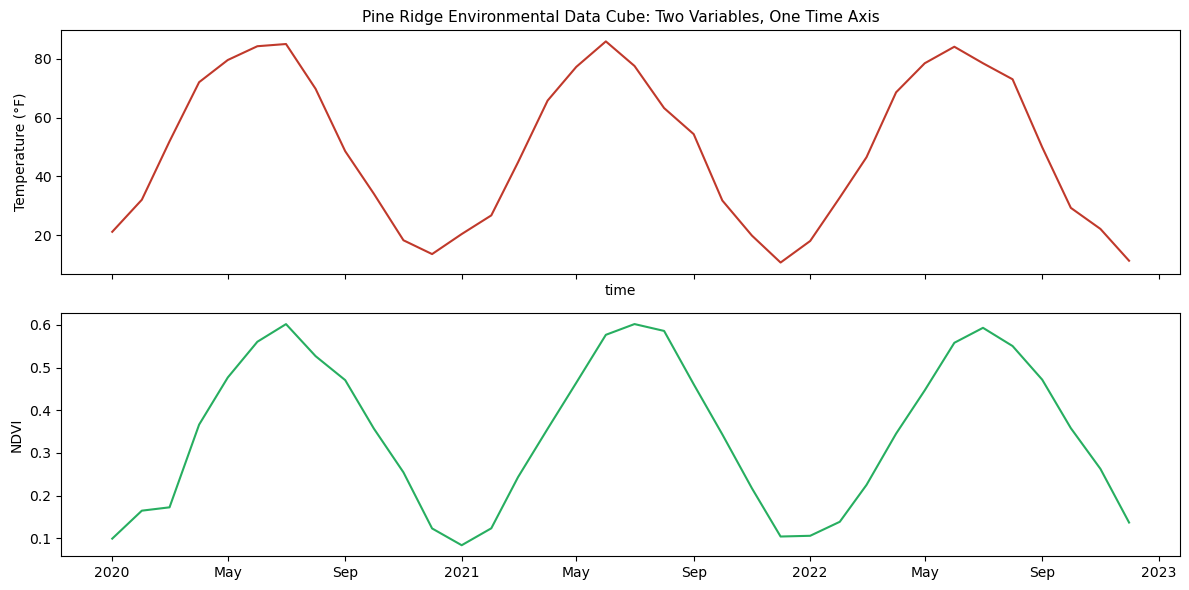


Notice how NDVI peaks in summer when temperature is high.
Vegetation responds to warmth. A drought year would show NDVI
staying low even in summer.


In [8]:
# With a Dataset, you can explore relationships between variables
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

cube["temperature_f"].plot(ax=ax1, color="#C0392B")
ax1.set_ylabel("Temperature (°F)")
ax1.set_title("Pine Ridge Environmental Data Cube: Two Variables, One Time Axis",
              fontsize=11)

cube["ndvi"].plot(ax=ax2, color="#27AE60")
ax2.set_ylabel("NDVI")
ax2.set_xlabel("")

plt.tight_layout()
plt.show()

print()
print("Notice how NDVI peaks in summer when temperature is high.")
print("Vegetation responds to warmth. A drought year would show NDVI")
print("staying low even in summer.")

## What Just Happened
You just built your first data cube:
- Two variables (`temperature_f` and `ndvi`)
- One dimension (`time`)
- Labeled coordinates so you can select by date, not by position
- Metadata attributes that document what the data is and where it comes from

In real Earth data science, the cubes are much larger and have multiple spatial
dimensions (latitude, longitude), hundreds of time steps, and multiple
variables. But the structure is exactly the same as what you just built.

## Discussion Questions
1. What other questions about Pine Ridge could a data cube help answer
   that a spreadsheet couldn't?

2. The data in this notebook is synthetic, made up to illustrate the
   concept. What real data sources would you want to use for a Pine Ridge
   data cube? (Hint: think about what you know about the land and
   environment there.)

3. From the data sovereignty reading: who should have authority over a
   data cube built from satellite data that covers Pine Ridge?

## Going Further
- xarray documentation: https://docs.xarray.dev/
- "What is a Data Cube?" from Open Data Cube: https://www.opendatacube.org/
- Earth Lab Earth Data Science textbook: https://www.earthdatascience.org/

## Next Notebook
**01 Arrays and Dimensions:** We'll go deeper into numpy and xarray by
building from 1D arrays to 3D spatial cubes, and understanding what
"dimensions" and "coordinates" really mean.